# Airbnb Investment Intelligence

## Data Understanding

### Project objective

The purpose of this project is to analyse Airbnb listings from nine major international cities to identify the factors associated with higher annual rental revenue. The analysis aims to support property investors by providing data-driven insights into the characteristics of successful Airbnb listings.

### Notebook objective

This notebook loads, combines and explores the raw datasets to understand their structure, identify potential data quality issues and prepare the data for further analysis.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

In [2]:
# Project directories

PROJECT_ROOT = Path.cwd().parent

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
TABLES_DIR = PROJECT_ROOT / "tables"

TABLES_DIR.mkdir(parents=True, exist_ok=True)

print(PROJECT_ROOT)
print(RAW_DATA_DIR)
print(PROCESSED_DATA_DIR)
print(TABLES_DIR)

c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business
c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\data\raw
c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\data\processed
c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\tables


In [3]:
csv_files = sorted(RAW_DATA_DIR.glob("*.csv"))
print(f"Number of datasets found: {len(csv_files)}\n")

for file in csv_files:
    print(file.name)

Number of datasets found: 9

DubaiData.csv
LAData.csv
LondonData.csv
MiamiData.csv
NYCData.csv
SanFransiscoData.csv
SydneyData.csv
TokyoData.csv
TorontoData.csv


## Load and combine datasets

The Airbnb data is provided as separate CSV files for different cities. To simplify the analysis, all datasets are loaded, labelled with their city of origin, and merged into a single DataFrame.

In [4]:
# Read and combine all Airbnb datasets

dataframes = []

for file in csv_files:
    df = pd.read_csv(file)
    # Create city name from file name
    city = file.stem.replace("Data", "")
    # Add city column
    df["City"] = city
    # Store Dataframe
    dataframes.append(df)

# Merge all cities into one dataframe
airbnb_df = pd.concat(dataframes, ignore_index=True)

print(f"Datasets combined: {len(dataframes)}")
print(f"Rows: {airbnb_df.shape[0]:,}")
print(f"Columns: {airbnb_df.shape[1]}")

Datasets combined: 9
Rows: 145,825
Columns: 57


## Explore the combined dataset

Before cleaning and modelling, the dataset is inspected to understand its structure, data types, and overall quality.

In [5]:
# Basic information about the dataset

print(f"Shape: {airbnb_df.shape}")

print("\nFirst 5 rows:")
display(airbnb_df.head())

print("\nColumn names:")
display(pd.DataFrame({"Column": airbnb_df.columns}))

print("\nData types:")
display(airbnb_df.dtypes.to_frame(name="Data Type"))

Shape: (145825, 57)

First 5 rows:


,Listing Title,Property Type,Listing Type,Created Date,Last Scraped Date,Country,City,Zipcode,Currency Native,Number of Reviews,...,Number of Bookings LTM,Number of Bookings LTM - Number of observed month,Average Daily Rate (USD),Average Daily Rate (Native),Annual Revenue LTM (USD),Annual Revenue LTM (Native),State,Last Host Count Updated Date,Neighbourhood,Metropolitan Statistical Area
0,Spacious & Private Townhome | 5 mins drive to ...,Entire rental unit,entire_home,2023-07-31,2024-01-10,AE,Dubai,25314,AED,1,...,9,6,145,532.1,3126,11472.4,NaN,NaN,NaN,NaN
1,Spacious and Ornate 2BR Apartment in Dubai South,Entire rental unit,entire_home,2023-07-31,2024-01-10,AE,Dubai,25314,AED,24,...,24,21,79,289.9,21815,80061.1,NaN,NaN,NaN,NaN
2,Exceptional 2BR near Expo City Dubai!,Entire rental unit,entire_home,2023-07-31,2024-01-10,AE,Dubai,25314,AED,13,...,14,11,70,256.9,14717,54011.4,NaN,NaN,NaN,NaN
3,Stylish Apartment Surrounded by Lush Green Parks!,Entire rental unit,entire_home,2023-07-31,2024-01-10,AE,Dubai,25314,AED,12,...,9,6,192,704.6,41775,153314.2,NaN,NaN,NaN,NaN
4,OFFER! 50% OFF! I am very cool and sleep 6!,Entire condo,entire_home,2023-07-31,2024-01-03,AE,Dubai,25314,AED,10,...,6,3,74,271.6,4461,16371.9,NaN,NaN,NaN,NaN



Column names:


,Column
0,Listing Title
1,Property Type
2,Listing Type
3,Created Date
4,Last Scraped Date
5,Country
6,City
7,Zipcode
8,Currency Native
9,Number of Reviews



Data types:


,Data Type
Listing Title,str
Property Type,str
Listing Type,str
Created Date,str
Last Scraped Date,str
Country,str
City,str
Zipcode,object
Currency Native,str
Number of Reviews,int64


## Data quality assessment

The dataset was examined for missing values, duplicate records and basic quality issues before further analysis.

In [6]:
# Missing values

missing = (
    airbnb_df.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing = missing[missing > 0]

display(
    pd.DataFrame({
        "Missing Values": missing,
        "Percentage": (missing / len(airbnb_df) * 100).round(2)
    })
)

,Missing Values,Percentage
Last Host Count Updated Date,145154,99.54
Neighbourhood,142340,97.61
Metropolitan Statistical Area,141362,96.94
License,117212,80.38
Cancellation Policy,63517,43.56
instant_bookable,63514,43.55
Host Listing Count,59101,40.53
Airbnb Cleanliness Rating,21646,14.84
Overall Rating,20851,14.30
Airbnb Value Rating,19494,13.37


In [7]:
duplicates = airbnb_df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

Duplicate rows: 0


In [8]:
airbnb_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145825 entries, 0 to 145824
Data columns (total 57 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   Listing Title                                      145819 non-null  str    
 1   Property Type                                      145825 non-null  str    
 2   Listing Type                                       145825 non-null  str    
 3   Created Date                                       145825 non-null  str    
 4   Last Scraped Date                                  145825 non-null  str    
 5   Country                                            145825 non-null  str    
 6   City                                               145825 non-null  str    
 7   Zipcode                                            129983 non-null  object 
 8   Currency Native                                    145825 non-null  str    
 9   Numb

## Numerical summary

A statistical summary of the numerical variables was generated to identify the range, distribution and potential anomalies within the dataset.

In [9]:
airbnb_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Number of Reviews,145825.0,3.754262e+01,6.949827e+01,0.000000,2.000000e+00,1.100000e+01,4.200000e+01,2.383000e+03
Bathrooms,145825.0,1.458481e+00,8.580419e-01,0.000000,1.000000e+00,1.000000e+00,2.000000e+00,4.200000e+01
Max Guests,145825.0,3.669823e+00,2.482226e+00,1.000000,2.000000e+00,3.000000e+00,4.000000e+00,4.200000e+01
Cleaning Fee (USD),140081.0,4.402559e+01,7.266315e+01,0.000000,0.000000e+00,0.000000e+00,6.800000e+01,1.957000e+03
Cleaning Fee (Native),140081.0,3.882268e+02,2.077500e+03,0.000000,0.000000e+00,0.000000e+00,8.060000e+01,1.113836e+05
Extra People Fee (USD),140081.0,3.309010e+00,9.857207e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,3.066330e+02
Extra People Fee(Native),140081.0,5.315047e+01,4.266809e+02,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,4.075810e+04
Minimum Stay,145825.0,8.163490e+00,2.099578e+01,1.000000,1.000000e+00,2.000000e+00,5.000000e+00,1.120000e+03
Latitude,145825.0,3.757580e+01,1.719756e+01,-34.095835,3.408105e+01,4.072500e+01,5.146451e+01,5.167629e+01
Longitude,145825.0,-2.240444e+01,7.648823e+01,-122.511360,-7.424394e+01,-7.325402e+01,-5.246196e-02,1.513401e+02


In [10]:
import matplotlib.pyplot as plt

# Project visual theme

plt.rcdefaults()

plt.rcParams.update({

    # Figure quality
    "figure.figsize": (10, 6),
    "figure.dpi": 120,
    "savefig.dpi": 300,

    # Fonts
    "font.family": "DejaVu Sans",
    "font.size": 11,

    "axes.titlesize": 14,
    "axes.titleweight": "bold",

    "axes.labelsize": 12,
    "axes.labelweight": "bold",

    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    # Cleaner appearance
    "axes.spines.top": False,
    "axes.spines.right": False,

    # Light grid
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "grid.alpha": 0.35,

    # Legend
    "legend.frameon": False
})

In [11]:
def save_figure(fig, number, filename, title):

    caption = f"Figure {number}. {title}"

    fig.text(
        0.5,
        0.015,
        caption,
        ha="center",
        fontsize=11,
        style="italic"
    )

    fig.tight_layout(rect=[0, 0.05, 1, 1])

    fig.savefig(
        PROJECT_ROOT / "figures" / filename,
        dpi=300,
        bbox_inches="tight"
    )

In [12]:
PROJECT_COLOURS = {

    "primary": "#1F77B4",
    "secondary": "#FF7F0E",
    "accent": "#2CA02C",
    "warning": "#D62728",
    "neutral": "#7F7F7F",
    "light": "#AEC7E8"

}

In [13]:
from openpyxl import Workbook
from openpyxl.styles import Alignment, Border, Font, PatternFill, Side
from openpyxl.utils import get_column_letter

In [14]:
# Table Export Function

def save_table_excel(
    dataframe,
    filename,
    caption,
    sheet_name="Table",
    decimal_places=2,
    percentage_columns=None,
    currency_columns=None,
    index=False
):
    """
    Save a pandas DataFrame as a formatted Excel workbook.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        DataFrame to export.

    filename : str
        Output filename, for example:
        'table_01_dataset_overview.xlsx'

    caption : str
        Caption placed above the table.

    sheet_name : str, default='Table'
        Excel worksheet name.

    decimal_places : int, default=2
        Number of decimal places for floating-point columns.

    percentage_columns : list, optional
        Columns that already contain percentage-point values,
        for example 35.5 for 35.5%.

    currency_columns : list, optional
        Columns to display using currency formatting.

    index : bool, default=False
        Whether to include the DataFrame index.
    """

    percentage_columns = percentage_columns or []
    currency_columns = currency_columns or []

    table_df = dataframe.copy()

    if index:
        table_df = table_df.reset_index()

    # Replace missing values with blank cells
    table_df = table_df.astype(object).where(
        pd.notna(table_df),
        None
    )

    workbook = Workbook()
    worksheet = workbook.active
    worksheet.title = sheet_name[:31]

    number_of_rows = len(table_df)
    number_of_columns = len(table_df.columns)

    first_column = 1
    last_column = number_of_columns

    header_row = 3
    data_start_row = header_row + 1
    data_end_row = data_start_row + number_of_rows - 1

    # Project colours
    primary_colour = PROJECT_COLOURS["primary"].replace("#", "")
    light_colour = PROJECT_COLOURS["light"].replace("#", "")

    white_colour = "FFFFFF"
    border_colour = "D9D9D9"
    alternate_row_colour = "F4F7FA"

    thin_border = Side(
        style="thin",
        color=border_colour
    )

    cell_border = Border(
        left=thin_border,
        right=thin_border,
        top=thin_border,
        bottom=thin_border
    )

    # Caption
    
    worksheet.merge_cells(
        start_row=1,
        start_column=first_column,
        end_row=1,
        end_column=last_column
    )

    caption_cell = worksheet.cell(
        row=1,
        column=1,
        value=caption
    )

    caption_cell.font = Font(
        name="Calibri",
        size=13,
        bold=True,
        italic=True
    )

    caption_cell.alignment = Alignment(
        horizontal="center",
        vertical="center"
    )

    worksheet.row_dimensions[1].height = 24

        # Column headers
    
    for column_number, column_name in enumerate(
        table_df.columns,
        start=1
    ):
        cell = worksheet.cell(
            row=header_row,
            column=column_number,
            value=str(column_name)
        )

        cell.fill = PatternFill(
            fill_type="solid",
            fgColor=primary_colour
        )

        cell.font = Font(
            name="Calibri",
            size=11,
            bold=True,
            color=white_colour
        )

        cell.alignment = Alignment(
            horizontal="center",
            vertical="center",
            wrap_text=True
        )

        cell.border = cell_border

    worksheet.row_dimensions[header_row].height = 30

        # Table data
    
    for row_offset, row_values in enumerate(
        table_df.itertuples(index=False, name=None),
        start=data_start_row
    ):
        for column_number, value in enumerate(
            row_values,
            start=1
        ):
            cell = worksheet.cell(
                row=row_offset,
                column=column_number,
                value=value
            )

            cell.font = Font(
                name="Calibri",
                size=10
            )

            cell.border = cell_border
            cell.alignment = Alignment(
                vertical="center",
                wrap_text=True
            )

            # Alternate row shading
            if (row_offset - data_start_row) % 2 == 1:
                cell.fill = PatternFill(
                    fill_type="solid",
                    fgColor=alternate_row_colour
                )

        worksheet.row_dimensions[row_offset].height = 21

        # Alignment and number formatting
    
    original_dataframe = dataframe.reset_index() if index else dataframe

    for column_number, column_name in enumerate(
        table_df.columns,
        start=1
    ):
        excel_column = get_column_letter(column_number)

        # First column left-aligned, remaining columns centred
        alignment = "left" if column_number == 1 else "center"

        for row_number in range(data_start_row, data_end_row + 1):
            worksheet.cell(
                row=row_number,
                column=column_number
            ).alignment = Alignment(
                horizontal=alignment,
                vertical="center",
                wrap_text=True
            )

        if column_name not in original_dataframe.columns:
            continue

        original_column = original_dataframe[column_name]

        # Percentage values such as 35.50 are shown as 35.50%
        if column_name in percentage_columns:
            number_format = (
                "0." + ("0" * decimal_places) + "%"
            )

            # Excel expects 0.355 for 35.5%, so divide by 100
            for row_number in range(data_start_row, data_end_row + 1):
                cell = worksheet.cell(
                    row=row_number,
                    column=column_number
                )

                if isinstance(cell.value, (int, float)):
                    cell.value = cell.value / 100
                    cell.number_format = number_format

        elif column_name in currency_columns:
            number_format = (
                '$#,##0'
                if decimal_places == 0
                else '$#,##0.' + ("0" * decimal_places)
            )

            for row_number in range(data_start_row, data_end_row + 1):
                worksheet.cell(
                    row=row_number,
                    column=column_number
                ).number_format = number_format

        elif pd.api.types.is_integer_dtype(original_column):
            for row_number in range(data_start_row, data_end_row + 1):
                worksheet.cell(
                    row=row_number,
                    column=column_number
                ).number_format = "#,##0"

        elif pd.api.types.is_float_dtype(original_column):
            number_format = (
                "#,##0"
                if decimal_places == 0
                else "#,##0." + ("0" * decimal_places)
            )

            for row_number in range(data_start_row, data_end_row + 1):
                worksheet.cell(
                    row=row_number,
                    column=column_number
                ).number_format = number_format

        # Automatic column widths
    
    for column_number, column_name in enumerate(
        table_df.columns,
        start=1
    ):
        excel_column = get_column_letter(column_number)

        content_lengths = [
            len(str(column_name))
        ]

        for value in table_df[column_name]:
            if value is not None:
                content_lengths.append(len(str(value)))

        maximum_length = max(content_lengths)

        if column_number == 1:
            column_width = min(
                max(maximum_length + 3, 20),
                42
            )
        else:
            column_width = min(
                max(maximum_length + 3, 12),
                22
            )

        worksheet.column_dimensions[
            excel_column
        ].width = column_width

        # Worksheet settings
   
    worksheet.freeze_panes = f"A{data_start_row}"

    worksheet.sheet_view.showGridLines = False

    worksheet.auto_filter.ref = (
        f"A{header_row}:"
        f"{get_column_letter(last_column)}{data_end_row}"
    )

    worksheet.page_setup.orientation = (
        "landscape"
        if number_of_columns > 5
        else "portrait"
    )

    worksheet.page_setup.fitToWidth = 1
    worksheet.page_setup.fitToHeight = 0
    worksheet.sheet_properties.pageSetUpPr.fitToPage = True

    worksheet.print_title_rows = f"1:{header_row}"

    worksheet.print_area = (
        f"A1:"
        f"{get_column_letter(last_column)}{data_end_row}"
    )

        # Save workbook
    
    output_path = TABLES_DIR / filename

    workbook.save(output_path)

    print(f"Table saved to: {output_path}")

In [15]:
# Table 1 summarises the size and structure of the combined Airbnb dataset.

dataset_overview = pd.DataFrame({
    "Measure": [
        "Source datasets",
        "Cities represented",
        "Total observations",
        "Total variables",
        "Duplicate rows"
    ],
    "Value": [
        len(dataframes),
        airbnb_df["City"].nunique(),
        airbnb_df.shape[0],
        airbnb_df.shape[1],
        airbnb_df.duplicated().sum()
    ]
})

display(dataset_overview)

save_table_excel(
    dataframe=dataset_overview,
    filename="table_01_dataset_overview.xlsx",
    caption="Table 1. Overview of the Combined Airbnb Dataset",
    sheet_name="Dataset Overview",
    decimal_places=0
)

,Measure,Value
0,Source datasets,9
1,Cities represented,9
2,Total observations,145825
3,Total variables,57
4,Duplicate rows,0


Table saved to: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\tables\table_01_dataset_overview.xlsx


In [16]:
# Table 2. Missing-data summary

missing_values_table = pd.DataFrame({
    "Variable": missing.index,
    "Missing Values": missing.values,
    "Missing Percentage (%)": (
        missing.values / len(airbnb_df) * 100
    )
})

missing_values_table = (
    missing_values_table
    .sort_values(
        by="Missing Percentage (%)",
        ascending=False
    )
    .reset_index(drop=True)
)

display(missing_values_table.head(15))

save_table_excel(
    dataframe=missing_values_table.head(15),
    filename="table_02_missing_values.xlsx",
    caption="Table 2. Variables with the Highest Levels of Missing Data",
    sheet_name="Missing Values",
    decimal_places=2,
    percentage_columns=["Missing Percentage (%)"]
)

,Variable,Missing Values,Missing Percentage (%)
0,Last Host Count Updated Date,145154,99.539859
1,Neighbourhood,142340,97.610149
2,Metropolitan Statistical Area,141362,96.939482
3,License,117212,80.378536
4,Cancellation Policy,63517,43.557003
5,instant_bookable,63514,43.554946
6,Host Listing Count,59101,40.528716
7,Airbnb Cleanliness Rating,21646,14.843820
8,Overall Rating,20851,14.298646
9,Airbnb Value Rating,19494,13.368078


Table saved to: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\tables\table_02_missing_values.xlsx


In [17]:
# Table 3. Descriptive statistics

summary_variables = [
    "Annual Revenue LTM (USD)",
    "Average Daily Rate (USD)",
    "Occupancy Rate LTM",
    "Number of Bookings LTM",
    "Bathrooms",
    "Max Guests",
    "Overall Rating",
    "Number of Reviews"
]

available_summary_variables = [
    column
    for column in summary_variables
    if column in airbnb_df.columns
    and pd.api.types.is_numeric_dtype(airbnb_df[column])
]

descriptive_table = (
    airbnb_df[available_summary_variables]
    .describe()
    .T[
        [
            "count",
            "mean",
            "std",
            "min",
            "25%",
            "50%",
            "75%",
            "max"
        ]
    ]
    .reset_index()
    .rename(columns={
        "index": "Variable",
        "count": "Count",
        "mean": "Mean",
        "std": "Standard Deviation",
        "min": "Minimum",
        "25%": "25th Percentile",
        "50%": "Median",
        "75%": "75th Percentile",
        "max": "Maximum"
    })
)

display(descriptive_table)

save_table_excel(
    dataframe=descriptive_table,
    filename="table_03_descriptive_statistics.xlsx",
    caption="Table 3. Descriptive Statistics for Selected Numerical Variables",
    sheet_name="Descriptive Statistics",
    decimal_places=2
)

,Variable,Count,Mean,Standard Deviation,Minimum,25th Percentile,Median,75th Percentile,Maximum
0,Annual Revenue LTM (USD),145825.0,17952.720343,25882.280447,2.0,2916.0,9150.0,23234.0,1290235.0
1,Average Daily Rate (USD),145825.0,198.687050,238.648368,1.0,86.0,143.0,235.0,33553.0
2,Occupancy Rate LTM,145825.0,67.050890,26.722573,1.0,46.0,70.0,92.0,100.0
3,Number of Bookings LTM,145825.0,16.133139,23.939186,0.0,1.0,6.0,21.0,251.0
4,Bathrooms,145825.0,1.458481,0.858042,0.0,1.0,1.0,2.0,42.0
5,Max Guests,145825.0,3.669823,2.482226,1.0,2.0,3.0,4.0,42.0
6,Overall Rating,124974.0,4.693068,0.466816,0.0,4.5,4.8,5.0,5.0
7,Number of Reviews,145825.0,37.542616,69.498271,0.0,2.0,11.0,42.0,2383.0


Table saved to: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\tables\table_03_descriptive_statistics.xlsx


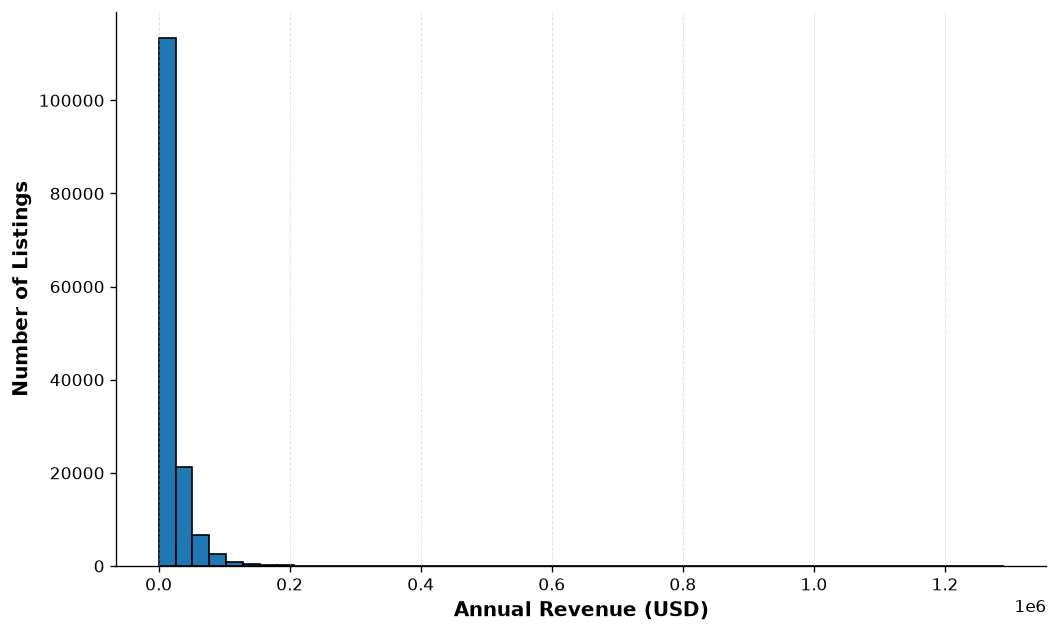

In [18]:
# Figure 1. Distribution of Annual Airbnb Revenue (USD)

fig, ax = plt.subplots()

ax.hist(
    airbnb_df["Annual Revenue LTM (USD)"],
    bins=50,
    color=PROJECT_COLOURS["primary"],
    edgecolor="black"
)

ax.set_xlabel("Annual Revenue (USD)")
ax.set_ylabel("Number of Listings")

ax.grid(axis="y")

if False:
    save_figure(
        fig,
        1,
        "figure_01_revenue_distribution.png",
        "Distribution of Annual Airbnb Revenue (USD)"
    )

plt.show()


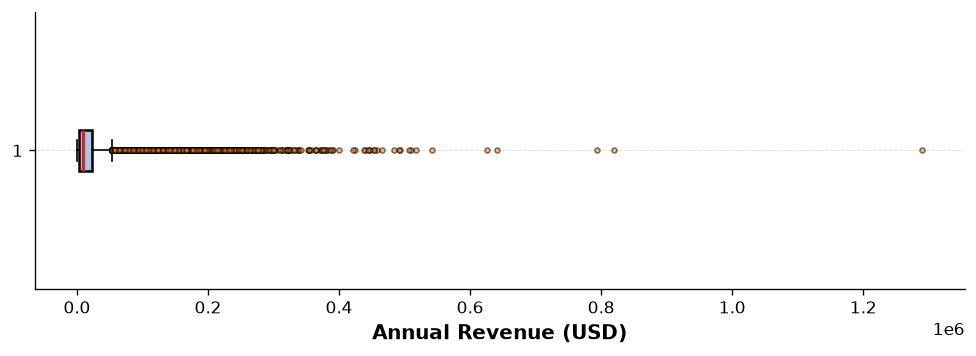

In [19]:
# Figure 2. Boxplot of Annual Airbnb Revenue (USD)

fig, ax = plt.subplots(figsize=(10, 3))

ax.boxplot(

    airbnb_df["Annual Revenue LTM (USD)"],

    orientation="horizontal",

    patch_artist=True,

    boxprops=dict(
        facecolor=PROJECT_COLOURS["light"],
        edgecolor="black",
        linewidth=1.5
    ),

    medianprops=dict(
        color=PROJECT_COLOURS["warning"],
        linewidth=2
    ),

    whiskerprops=dict(
        color="black"
    ),

    capprops=dict(
        color="black"
    ),

    flierprops=dict(
        marker="o",
        markerfacecolor=PROJECT_COLOURS["secondary"],
        markeredgecolor="black",
        markersize=3,
        alpha=0.5
    )

)

ax.set_xlabel("Annual Revenue (USD)")

ax.grid(axis="x")

if False:
    save_figure(
    fig,
    2,
    "figure_02_revenue_boxplot.png",
    "Boxplot of Annual Airbnb Revenue (USD)"
)

plt.show()

## Distribution of Key Categorical Variables

This section explores the main categorical variables within the Airbnb dataset. Understanding the distribution of listings across cities, property types and room types provides valuable context for subsequent data cleaning and exploratory analysis.

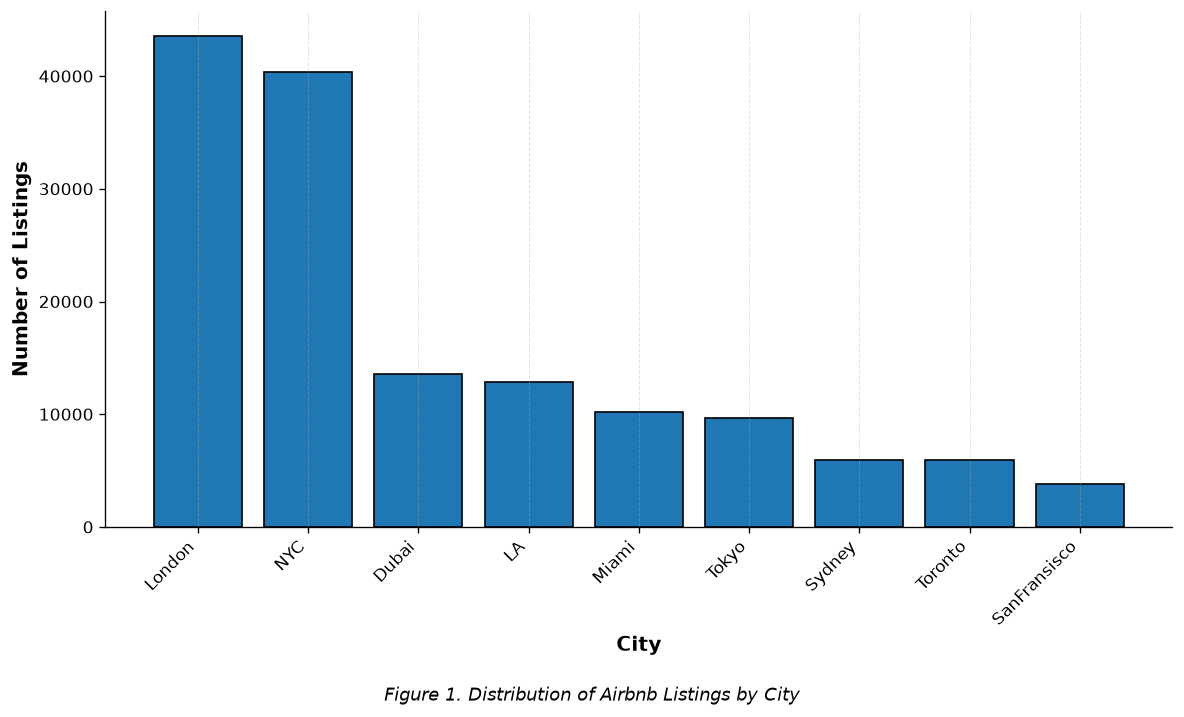

In [20]:
# Figure 3. Distribution of Airbnb Listings by City

city_counts = (
    airbnb_df["City"]
    .value_counts()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots()

ax.bar(
    city_counts.index,
    city_counts.values,
    color=PROJECT_COLOURS["primary"],
    edgecolor="black"
)

ax.set_xlabel("City")
ax.set_ylabel("Number of Listings")

ax.tick_params(
    axis="x",
    rotation=45
)

for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

ax.grid(axis="y")

#if False:
save_figure(
    fig,
    1,
    "figure_01_listings_by_city.png",
    "Distribution of Airbnb Listings by City"
)

plt.show()

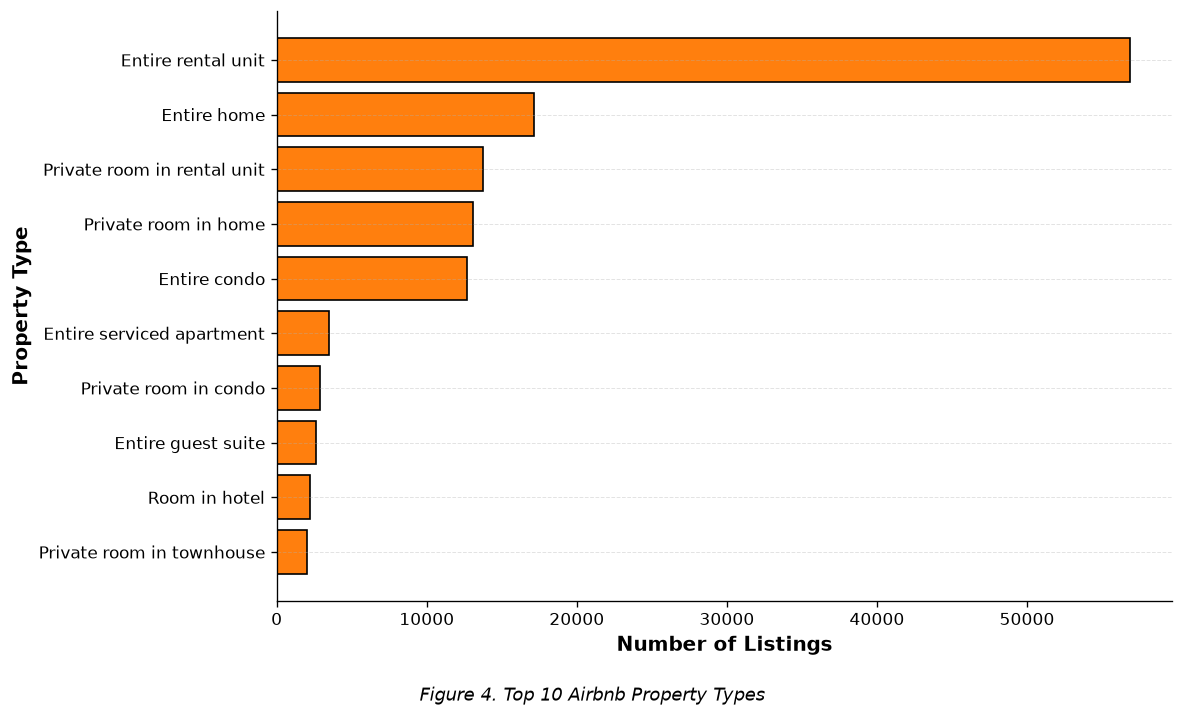

In [46]:
# Figure 4. Top Property Types

property_counts = (
    airbnb_df["Property Type"]
    .value_counts()
    .head(10)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots()

ax.barh(
    property_counts.index,
    property_counts.values,
    color=PROJECT_COLOURS["secondary"],
    edgecolor="black"
)

ax.set_xlabel("Number of Listings")
ax.set_ylabel("Property Type")

ax.grid(axis="x")

save_figure(
    fig,
    4,
    "figure_04_top_property_types.png",
    "Top 10 Airbnb Property Types"
)

plt.show()

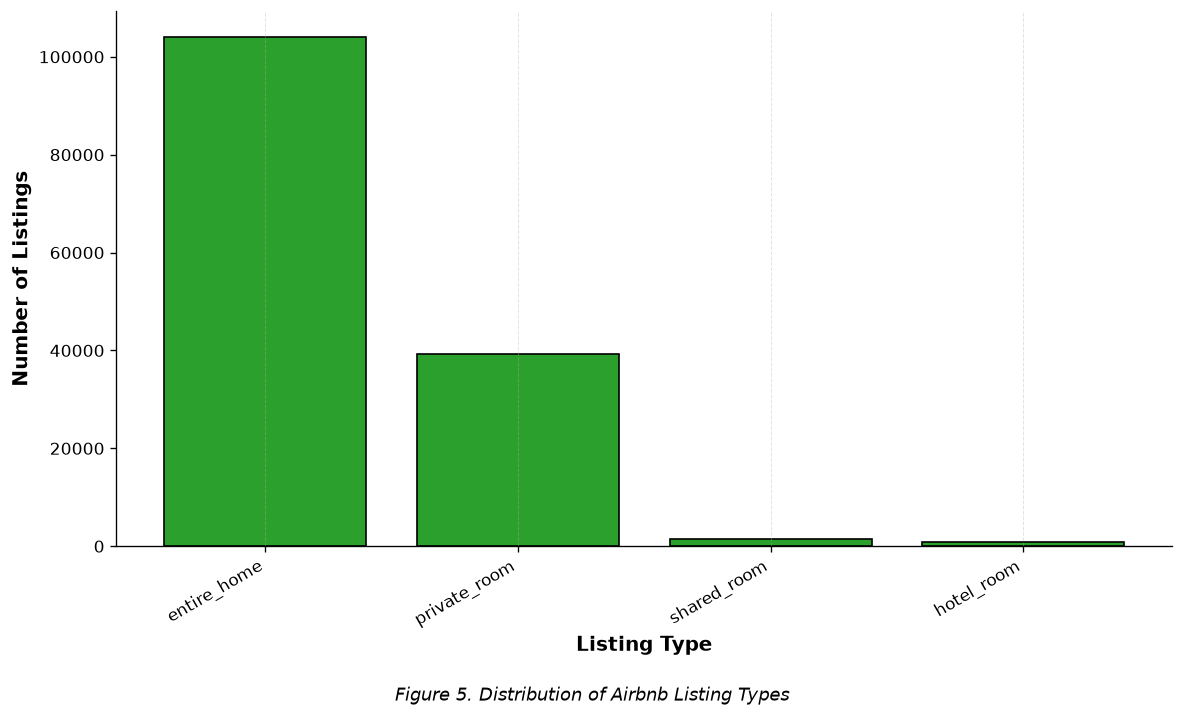

In [47]:
# Figure 5. Distribution of Listing Types

listing_type_counts = (
    airbnb_df["Listing Type"]
    .value_counts()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots()

ax.bar(
    listing_type_counts.index,
    listing_type_counts.values,
    color=PROJECT_COLOURS["accent"],
    edgecolor="black"
)

ax.set_xlabel("Listing Type")
ax.set_ylabel("Number of Listings")

ax.tick_params(
    axis="x",
    rotation=30
)

for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

ax.grid(axis="y")

save_figure(
    fig,
    5,
    "figure_05_listing_types.png",
    "Distribution of Airbnb Listing Types"
)

plt.show()

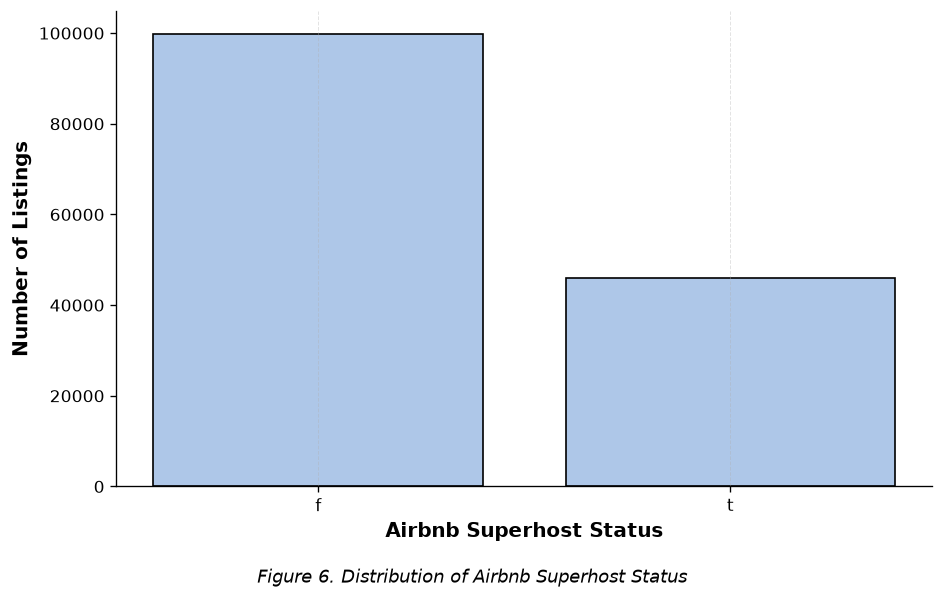

In [48]:
# Figure 6. Airbnb Superhost Status

superhost_counts = (
    airbnb_df["Airbnb Superhost"]
    .fillna("Missing")
    .astype(str)
    .value_counts()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    superhost_counts.index,
    superhost_counts.values,
    color=PROJECT_COLOURS["light"],
    edgecolor="black"
)

ax.set_xlabel("Airbnb Superhost Status")
ax.set_ylabel("Number of Listings")

ax.grid(axis="y")

save_figure(
    fig,
    6,
    "figure_06_superhost_status.png",
    "Distribution of Airbnb Superhost Status"
)

plt.show()

In [51]:
airbnb_df.to_csv(
    PROCESSED_DATA_DIR / "airbnb_combined_raw.csv",
    index=False
)

print("Combined dataset saved successfully.")

Combined dataset saved successfully.
